# Experiment 3 — Observability: when usage is invisible, what can seeding do?

> **⚠ ALL DATA IS SYNTHETIC** ([`docs/limitations.md`](../docs/limitations.md)).

**The question (decision [D17](../docs/decisions.md), arbitration 2026-06-10).** Real
AI usage is largely invisible: it happens in a browser tab; colleagues see outputs,
not methods. The model so far assumed every adopted contact generates exposure
(visibility v = 1). D17 introduces v ∈ [0, 1]: an adopted contact j contributes
v_j · w_ij to a neighbor's exposure — the contact still counts among one's credible
voices (denominator unchanged); their *adoption* is just partially visible. The
broadcast comms term stays fully visible: a broadcast is loud by nature.

The scientist's hypothesis going in: *invisibility may be exactly what devalues
scattered seeds in reality* — i.e. v < 1 might rescue cluster seeding from the D16
negative result. This notebook answers that twice (spoiler: no, and instructively no),
and measures the ratified intervention: **observable pilots** — seeds carry v = 1
("work out loud" rituals) while the rest of the organization sits at v < 1. An
intervention on the pilot cohort, not a structural assumption.

**What "adoption" means here (definitional note, ratified with D17):** the *costly
production behavior* — genuinely reorganizing how one works around the tool — not
shallow substitution use (search-bar replacement), which spreads as simple contagion,
needs no critical mass, and is out of scope.

Runtime: ~1–2 minutes (multi-core).

In [1]:
import sys, pathlib, time
HERE = pathlib.Path.cwd().resolve()
REPO = HERE if (HERE / "core").exists() else HERE.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "experiments"))

import numpy as np, matplotlib.pyplot as plt
import core, exp3, plotting
from core.dynamics import SimParams, draw_agents, run_simulation
from core.orggen import generate_org
from core.scenario import org_kwargs
from core.seeding import make_seeding

T0 = time.time()
SC = exp3.base_scenario()
print(f"adoption-sim {core.__version__} · scenario: headline (D16) + visibility axis (D17)")

adoption-sim 0.1.0 · scenario: headline (D16) + visibility axis (D17)


## 1. A theorem first: global invisibility is just higher thresholds

For v > 0 and any scenario without a broadcast term, every condition in the dynamics
transforms identically:

$$\frac{v \cdot A_i(t)}{W_i} \geq \theta_i \iff \frac{A_i(t)}{W_i} \geq \frac{\theta_i}{v}$$

— and the same holds for the awareness clause (share > 0) and the relapse condition
(share < r·θᵢ). So **a global visibility v with thresholds {θᵢ} produces the
bit-for-bit identical trajectory as v = 1 with thresholds {θᵢ/v}**
(`tests/test_visibility.py::test_theta_over_v_equivalence_exact` verifies this
exactly, including under decay). Two consequences:

1. A *global* v cannot reorder the seeded strategies — it slides everyone along the
   θ̄ sensitivity axis together. The D16 negative result (scattered ≥ cluster) is
   **provably v-invariant**. Below we confirm it empirically anyway, because proofs
   about code deserve witnesses.
2. The only way visibility can *differentially* matter is if it differs across
   agents — which is exactly what the observable-pilots intervention does.

The broadcast strategy is the one exception (its comms term is fully visible), so
low v improves broadcast's *relative* standing — by leaving it alone while
everything else sinks.

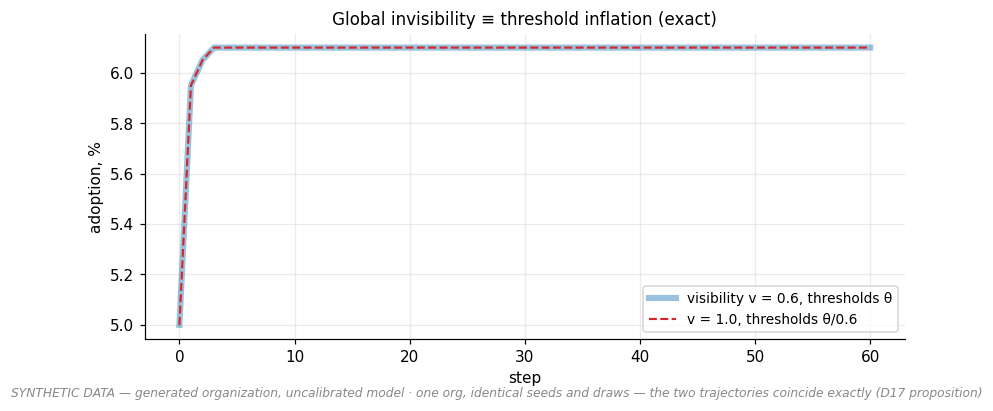

max |difference| between the two curves: 0.0


In [2]:
# Witness the equivalence on one organization: v=0.6 vs thresholds/0.6 — identical.
org_w = generate_org(**org_kwargs(SC), seed=33)
cw = org_w.compile()
p0 = SimParams(max_steps=60)
theta, willing, able = draw_agents(cw, p0, np.random.default_rng(8))
seeding_w = make_seeding("cluster", cw, 0.05, rng=8)
r_v = run_simulation(cw, SimParams(max_steps=60, visibility=0.6), seeding_w, rng=9,
                     agents=(theta, willing, able))
r_t = run_simulation(cw, SimParams(max_steps=60, visibility=1.0), seeding_w, rng=9,
                     agents=(theta / 0.6, willing, able))
assert np.array_equal(r_v.curve, r_t.curve)

fig, ax = plotting.fig_with_stamp(figsize=(7.5, 3.6),
    note="one org, identical seeds and draws — the two trajectories coincide exactly (D17 proposition)")
ax.plot(100 * r_v.curve, lw=4, color="#1f77b4", alpha=0.45, label="visibility v = 0.6, thresholds θ")
ax.plot(100 * r_t.curve, lw=1.4, color="#d62728", linestyle="--", label="v = 1.0, thresholds θ/0.6")
ax.set_xlabel("step"); ax.set_ylabel("adoption, %")
ax.set_title("Global invisibility ≡ threshold inflation (exact)", fontsize=11)
ax.legend(fontsize=9)
plotting.save_fig(fig, REPO / "figures" / "exp3_equivalence.png")
plt.show()
print("max |difference| between the two curves:", float(np.abs(r_v.curve - r_t.curve).max()))

## 2. Global visibility sweep — the proof gets its witness

All five strategies at v ∈ {0.4, 0.6, 0.8, 1.0}, frozen headline regime otherwise.
Read it as the θ̄ axis in disguise: v = 0.8 means θ_eff = 0.375, v = 0.6 means 0.5.

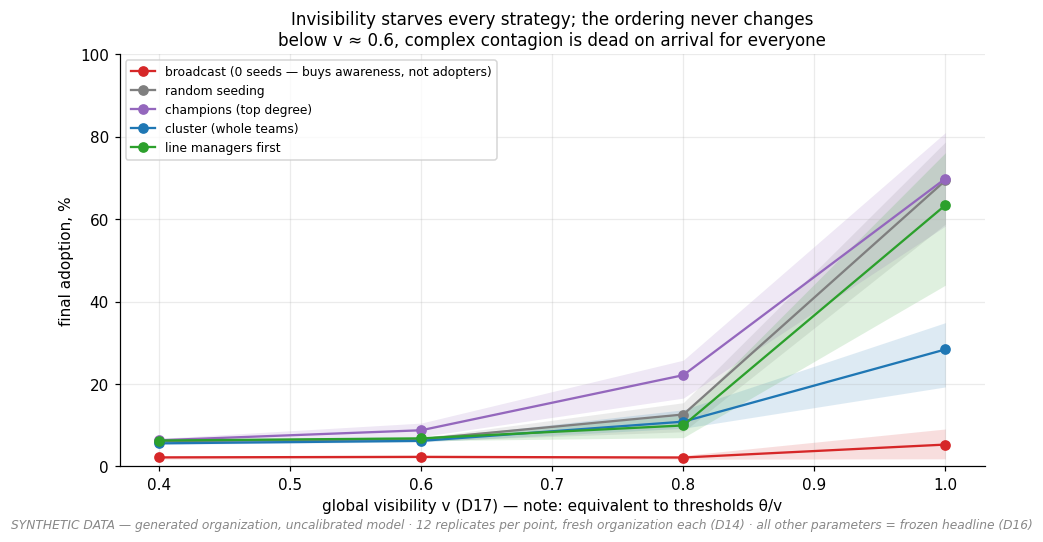

v=0.4  broadcast:   2.2%  random:   6.1%  champions:   6.3%  cluster:   5.6%  line_manager_first:   6.3%
v=0.6  broadcast:   2.3%  random:   6.6%  champions:   8.8%  cluster:   6.2%  line_manager_first:   6.8%
v=0.8  broadcast:   2.2%  random:  12.6%  champions:  22.1%  cluster:  10.9%  line_manager_first:   9.9%
v=1.0  broadcast:   5.3%  random:  69.4%  champions:  69.8%  cluster:  28.4%  line_manager_first:  63.4%


In [3]:
gl_rows = exp3.run_global_v_sweep(SC)
gl = {}
for r in gl_rows:
    gl.setdefault((r["seeding.strategy"], float(r["agents.visibility"])), []).append(r["final_rate"])

fig, ax = plotting.fig_with_stamp(figsize=(8.5, 4.8),
    note="12 replicates per point, fresh organization each (D14) · all other parameters = frozen headline (D16)")
for strat in exp3.ALL_STRATEGIES:
    m = [np.mean(gl[(strat, v)]) * 100 for v in exp3.V_AXIS]
    lo = [np.percentile(gl[(strat, v)], 10) * 100 for v in exp3.V_AXIS]
    hi = [np.percentile(gl[(strat, v)], 90) * 100 for v in exp3.V_AXIS]
    c = plotting.STRATEGY_COLORS[strat]
    ax.plot(exp3.V_AXIS, m, "o-", color=c, label=plotting.STRATEGY_LABELS[strat])
    ax.fill_between(exp3.V_AXIS, lo, hi, color=c, alpha=0.15, linewidth=0)
ax.set_xlabel("global visibility v (D17) — note: equivalent to thresholds θ/v")
ax.set_ylabel("final adoption, %")
ax.set_ylim(0, 100)
ax.set_title("Invisibility starves every strategy; the ordering never changes\n"
             "below v ≈ 0.6, complex contagion is dead on arrival for everyone", fontsize=11)
ax.legend(fontsize=8)
plotting.save_fig(fig, REPO / "figures" / "exp3_globalv.png")
plt.show()
for v in exp3.V_AXIS:
    print(f"v={v:.1f}  " + "  ".join(f"{s}: {np.mean(gl[(s, v)]):6.1%}" for s in exp3.ALL_STRATEGIES))

### Reading it

- **No reordering anywhere** — cluster never overtakes random at any v, exactly as
  the equivalence requires. The hypothesis "global invisibility is what devalues
  scattered seeds" is **refuted in this model family**: invisibility devalues
  *everyone's* seeds, in proportion.
- **The cliff is brutal.** At v = 0.8 every strategy loses most of its reach
  (random 69% → 13%, cluster 28% → 11%); at v ≤ 0.6 nothing exceeds ~9% — effective
  thresholds of θ̄/v ≥ 0.5 exceed almost the entire workforce. If real usage of a
  tool is mostly invisible, **the binding constraint is visibility itself, not the
  seeding strategy.**
- **Champions degrade slowest** (22% at v = 0.8 vs random's 13%): hubs accumulate
  many small attenuated exposures and convert their huge neighborhoods' tails.
- Broadcast's *absolute* take barely moves (its innovators convert via the loud comms
  channel) — at v ≤ 0.6 the formerly worst strategy is suddenly competitive with
  everything, by standing still while the rest drown.

## 3. The intervention: observable pilots ("work out loud")

Seeds carry v = 1.0 — they demo in meetings, narrate their workflow — while everyone
else's adoption stays partially visible (v_global ∈ {0.4, 0.6, 0.8}). Applied
identically to cluster, random, and champions seeds: same headcount, same ritual,
different *placement*. (Broadcast has no seeds to make loud; line-managers-first
omitted for focus.)

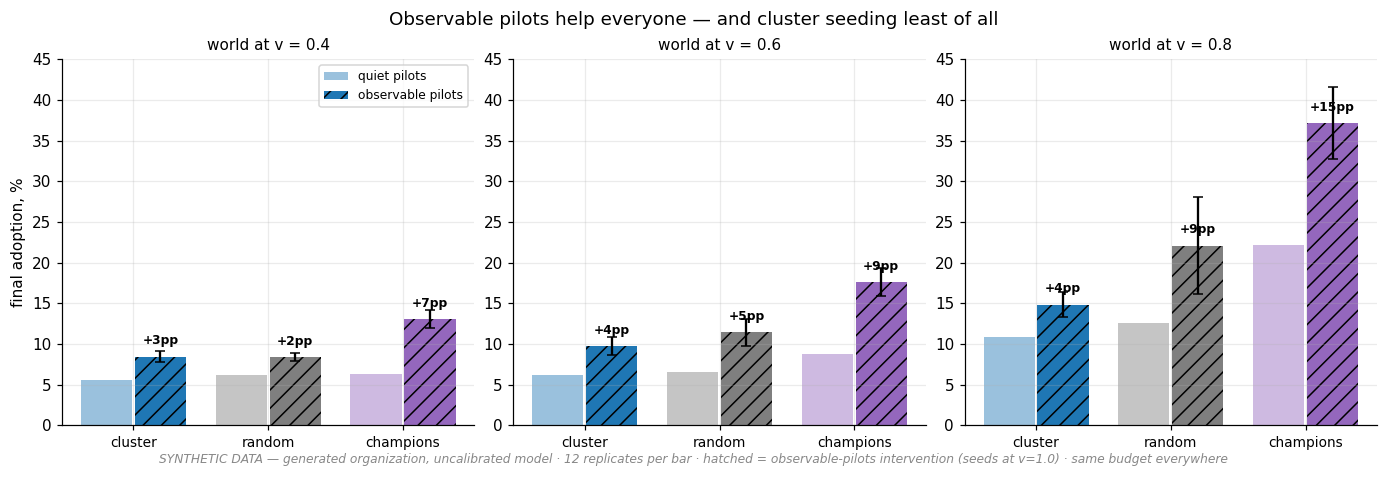

v_global=0.4: cluster  5.6%→ 8.4%  random  6.1%→ 8.3%  champions  6.3%→13.1%
v_global=0.6: cluster  6.2%→ 9.8%  random  6.6%→11.4%  champions  8.8%→17.6%
v_global=0.8: cluster 10.9%→14.8%  random 12.6%→22.1%  champions 22.1%→37.2%


In [4]:
pi_rows = exp3.run_observable_pilots(SC)
pi = {}
for r in pi_rows:
    pi.setdefault((r["seeding.strategy"], float(r["agents.visibility"])), []).append(r["final_rate"])

fig, axes = plotting.fig_with_stamp(1, 3, figsize=(12.5, 4.2),
    note="12 replicates per bar · hatched = observable-pilots intervention (seeds at v=1.0) · same budget everywhere")
for ax, vg in zip(axes, exp3.PILOT_V_GLOBALS):
    xs = np.arange(len(exp3.PILOT_STRATEGIES))
    base = [np.mean(gl[(s, vg)]) * 100 for s in exp3.PILOT_STRATEGIES]
    loud = [np.mean(pi[(s, vg)]) * 100 for s in exp3.PILOT_STRATEGIES]
    loud_sd = [np.std(pi[(s, vg)]) * 100 for s in exp3.PILOT_STRATEGIES]
    colors = [plotting.STRATEGY_COLORS[s] for s in exp3.PILOT_STRATEGIES]
    ax.bar(xs - 0.2, base, width=0.38, color=colors, alpha=0.45, label="quiet pilots")
    ax.bar(xs + 0.2, loud, width=0.38, color=colors, hatch="//", yerr=loud_sd,
           capsize=3, label="observable pilots")
    for x, b, l in zip(xs, base, loud):
        ax.text(x + 0.2, l + 1.5, f"+{l - b:.0f}pp", ha="center", fontsize=8, fontweight="bold")
    ax.set_xticks(xs, exp3.PILOT_STRATEGIES, fontsize=9)
    ax.set_ylim(0, 45)
    ax.set_title(f"world at v = {vg}", fontsize=10)
axes[0].set_ylabel("final adoption, %")
axes[0].legend(fontsize=8)
fig.suptitle("Observable pilots help everyone — and cluster seeding least of all", fontsize=12)
plotting.save_fig(fig, REPO / "figures" / "exp3_pilots.png")
plt.show()
for vg in exp3.PILOT_V_GLOBALS:
    print(f"v_global={vg}: " + "  ".join(
        f"{s} {np.mean(gl[(s, vg)]):5.1%}→{np.mean(pi[(s, vg)]):5.1%}" for s in exp3.PILOT_STRATEGIES))

### The verdict the hypothesis didn't want — and the mechanism behind it

**The intervention does not rescue cluster seeding either.** At every v_global,
loud pilots help scattered strategies *more*: at v = 0.8, cluster gains ~+4 pp while
random gains ~+10 pp and champions ~+15 pp. Cluster never overtakes random under any
tested condition. Reported as committed (D16/D17): this model family simply does not
contain the folklore ordering, with or without visibility effects.

**Why — measured, not guessed.** Loudness only does new work on ties that point at
people who haven't adopted yet. A pilot *team's* members spend most of their
credibility on each other — already adopted, nothing to convert:

| seed type | outward credibility per seed (mean over 5 orgs) |
|---|---|
| cluster (whole teams) | **5.7** — most ties point inward at fellow pilots |
| random individuals | **11.7** — a full personal network each |
| champions (hubs) | **16.1** — large networks, all outward |

The intervention gains line up with that column almost proportionally. The
work-out-loud ritual is a *megaphone*; megaphones are wasted in a room where
everyone already agrees.

**The actionable reading (within the model's many limits):** if usage of your tool
is mostly invisible, (1) the highest-leverage move is raising *global* visibility —
shared channels, visible artifacts, defaults that expose usage — because below
v ≈ 0.6 no seeding strategy works at all; and (2) visibility rituals are best spent
on **well-connected individuals**, not on pilot teams, whose loudness mostly echoes
inside the room. Cluster seeding's case remains what experiment 1 found: not reach,
but **retention** under decay.

## 4. What this experiment establishes

1. **Theorem + witness:** global visibility v is exactly threshold inflation θ/v
   (exact unit test; empirical sweep). Global invisibility therefore cannot reorder
   seeded strategies — the D16 negative result is v-invariant.
2. **The scientist's going-in hypothesis is refuted twice** (and reported, per the
   honesty rules): neither global v < 1 nor the observable-pilots intervention
   rescues cluster seeding; the intervention actively favors scattered and
   hub-based seeding, in proportion to outward credibility per seed.
3. **Visibility is a first-order constraint:** below v ≈ 0.6 in this regime,
   complex contagion dies for every strategy. A tool nobody sees being used is a
   tool nobody copies — regardless of pilot design.
4. Broadcast is the only strategy *unhurt* by invisibility (its channel is loud by
   definition) — at low v it becomes competitive by default, a genuinely
   non-obvious implication.

**Provenance:** scenario = frozen headline (D16) + D17 axis · CSVs + metadata in
`experiments/results/exp3_*.csv` · all figures stamped synthetic · runtime below.

In [5]:
# --- provenance footer (release standard) ---
import platform, numpy, networkx
print("=" * 72)
print("PROVENANCE — experiment 3 (observability, D17)")
print(f"scenario: frozen headline (D16) + visibility axis · master seed {SC['run']['master_seed']}")
print("decision log: D1-D17 RATIFIED 2026-06-10 (docs/decisions.md)")
print(f"adoption-sim {core.__version__} · numpy {numpy.__version__} · networkx {networkx.__version__} · python {platform.python_version()}")
print("ALL DATA SYNTHETIC — see docs/limitations.md (esp. entries 13-14, 19)")
print(f"total runtime: {time.time()-T0:.0f}s")
print("results:", *(p.name for p in sorted((REPO / 'experiments' / 'results').glob('exp3_*'))), sep="\n  ")

PROVENANCE — experiment 3 (observability, D17)
scenario: frozen headline (D16) + visibility axis · master seed 20260610
decision log: D1-D17 RATIFIED 2026-06-10 (docs/decisions.md)
adoption-sim 0.1.0 · numpy 2.4.6 · networkx 3.6.1 · python 3.13.13
ALL DATA SYNTHETIC — see docs/limitations.md (esp. entries 13-14, 19)
total runtime: 26s
results:
  exp3_globalv.csv
  exp3_globalv.meta.json
  exp3_pilots.csv
  exp3_pilots.meta.json
